# This notebook assembles BEEF correlations [calculated by the Goldsmith group](https://github.com/franklingoldsmith/thermo_kinetics_scripts) and exports them to an RMG-UQ compatible format

### Part 1. surfaceThermoPt111 library correlations
### Part 2. Pt111 adsorption correction tree correlations


In [1]:
import os
import re
import sys
import pickle
import numpy as np
import pandas as pd
import shutil
import glob
import subprocess

import rmgpy.data.thermo
import rmgpy.data.rmg
import rmgpy.chemkin

import matplotlib.pyplot as plt
%matplotlib inline

# Part 0: Setup
### - Download the repository containing the surface thermo calculations
### - Set the `THERMO_DATA_PATH` variable

Unfortunately, the exact locations of these files might change as the repo gets updated, but we're looking for folder titled `beef-ensembles` which is full of files like XCHOO_bee.txt that contain the ensemble data. This is **Option A**.

Alternatively, these values may be saved in Python dictionaries like `beefdict.py` https://github.com/kirkbadger18/thermo_kinetics_scripts/tree/main/new_workflow/examples/build_ensemble/data. This is **Option B**. This script contains examples for using both sources, but you should use whichever workflow corresponds to the latest updates in surfaceThermoPt111.

### You can manually download the repository here: https://github.com/franklingoldsmith/thermo_kinetics_scripts or run the next cell

In [2]:
# # These are the commands:
# os.chdir(os.environ['HOME'])  # assumes we will clone thermo_kinetics_scripts into our home folder

THERMO_DATA_PATH = os.path.join(os.environ['HOME'], 'thermo_kinetics_scripts/beef-uq/thermo/beef-ensembles')
# example_bee_file = os.path.join(THERMO_DATA_PATH, 'XH_bee.txt')

# if not os.path.exists(example_bee_file):
#     subprocess.check_call(['git', 'clone', 'https://github.com/franklingoldsmith/thermo_kinetics_scripts'])

# assert os.path.exists(example_bee_file), 'either download failed or file structure of repo has changed'

# Part 1: surfaceThermoPt111 library correlations

## **Option A:**    XCHOO_bee.txt files 

### A1.1 Load the copy of surfaceThermoPt111.py in this repository to get the molecule structures

In [3]:
# load their thermo library
thermo_lib_file = os.path.join(os.environ['HOME'], 'thermo_kinetics_scripts/beef-uq/thermo/surfaceThermoPt111.py')

# RMG expects the library in its own directory
lib_dir = os.path.join(os.path.dirname(thermo_lib_file), 'lib')
os.makedirs(lib_dir, exist_ok=True)
shutil.copyfile(thermo_lib_file, os.path.join(lib_dir, os.path.basename(thermo_lib_file)))

thermo_database = rmgpy.data.thermo.ThermoDatabase()
thermo_database.load_libraries(lib_dir)

# Make a list of each molecule and each label
items = [thermo_database.libraries['surfaceThermoPt111'].entries[e].item for e in thermo_database.libraries['surfaceThermoPt111'].entries]
labels = [thermo_database.libraries['surfaceThermoPt111'].entries[e].label for e in thermo_database.libraries['surfaceThermoPt111'].entries]

INFO:root:Loading thermodynamics library from surfaceThermoPt111.py in /home/moon/thermo_kinetics_scripts/beef-uq/thermo/lib...


### A1.2 Load all the data from the BEE files

In [4]:
def get_name_from_path(path):
    search_pattern = r'beef-ensembles/(.+)_bee.txt'
    m1 = re.search(search_pattern, path)
    if m1 is not None:
        return m1[1]
bee_files = sorted(glob.glob(os.path.join(THERMO_DATA_PATH, '*_bee.txt')))

### A1.3 Function to match BEEF data to names in library

In [5]:
def get_molecule_by_name(sp_name):
    # Get the molecule that matches the name in the BEEF thermo library
    try:
        entry_index = labels.index(sp_name)
        return items[entry_index]
    except ValueError:
        print(f'Could not find {i} {sp_name} in thermo library')
        return None

### A1.4 Load BEEF thermo ensemble data and corresponding molecule structure

In [6]:
Hf_ensemble_data = []
molecules = []
for i in range(len(bee_files)):
    species_name = get_name_from_path(bee_files[i])
    molecule = get_molecule_by_name(species_name)
    if molecule is None:
        continue
    molecules.append(molecule)

    species_ensemble_data = []
    # the loaded dataframe has 2 columns: Hf and Delta Hf
    df = pd.read_csv(bee_files[i], sep='\t')
    Hf_ensemble_data.append(df['Hf'].values)

Hf_ensemble_data = np.array(Hf_ensemble_data)

assert Hf_ensemble_data.shape[1] == 2000, 'BEEF ensemble size should be 2000'

N_species = Hf_ensemble_data.shape[0]
print(f'{N_species} species loaded')

cov_Hf = np.cov(Hf_ensemble_data)
assert cov_Hf.shape[0] == N_species
assert len(molecules) == N_species

Could not find 18 CH3OXCO in thermo library
182 species loaded


## **Option B:** Python dictionary

### B1.1 Import all the data from the Python readable files

In [7]:
sys.path.append('/home/moon/thermo_kinetics_scripts/new_workflow/')  # folder containing class definitions
import adsorbate


sys.path.append('/home/moon/thermo_PR_data/data')  # folder containing data
from Pt111_ads_data import Pt111_ads_data
from reference_data import reference_dict
from slab_data import slab_dict
from beefdict import beefdict
from refbeefdict import refbeefdict

# reformat the reference_dict to use 'Pt' instead of 'slab'
reference_dict['reference_compositions']['Pt'] = reference_dict['reference_compositions']['slab']
reference_dict['reference_energies']['Pt'] = reference_dict['reference_energies']['slab']
reference_dict['reference_EOF']['Pt'] = reference_dict['reference_EOF']['slab']
reference_dict['EOF_uncertainty']['Pt'] = reference_dict['EOF_uncertainty']['slab']

reference_dict['reference_compositions'].pop('slab')
reference_dict['reference_energies'].pop('slab')
reference_dict['reference_EOF'].pop('slab')
reference_dict['EOF_uncertainty'].pop('slab')

0

### B1.2 Save the ensemble of databases (takes up ~350MB on disk)

In [8]:
all_ads = adsorbate.AdsorbatesEnsemble(
    Pt111_ads_data,
    reference_dict,
    slab_dict,
    'a long description',
    beefdict,
    refbeefdict,
)

all_ads.get_RMG_thermo_database_entries()
ensemble_db_location = 'ensemble_databases/'
os.makedirs(ensemble_db_location, exist_ok=True)
all_ads.write_ensemble_of_RMG_thermodatabase_files(directory=ensemble_db_location)

### B1.2 For every adsorbate in Pt111_ads_data, compute H298 using the 2000 BEEF-vdW DFT energies

In [9]:
rmg_thermo_db = rmgpy.data.thermo.ThermoDatabase()
rmg_thermo_db.load_libraries(ensemble_db_location)

INFO:root:Loading thermodynamics library from database_716.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_1690.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_1867.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_1513.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_387.py in ensemble_databases/...


...

INFO:root:Loading thermodynamics library from database_256.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_1154.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_1009.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_242.py in ensemble_databases/...


INFO:root:Loading thermodynamics library from database_1029.py in ensemble_databases/...


In [10]:
molecule_order = list(rmg_thermo_db.libraries['database_0'].entries.keys())
molecules = [value.item for key, value in rmg_thermo_db.libraries['database_0'].entries.items()]
molecule_labels = [rmg_thermo_db.libraries['database_0'].entries[x].label for x in rmg_thermo_db.libraries['database_0'].entries]

Hf_ensemble_data = np.zeros((len(molecule_order), 2000))

for i in range(2000):
    library_name = f'database_{i}'
    for j in range(len(molecule_order)):
        Hf_ensemble_data[j, i] = rmg_thermo_db.libraries[library_name].entries[molecule_order[j]].data.get_enthalpy(298) / 1000.0  # convert to kJ/mol
cov_Hf = np.cov(Hf_ensemble_data)


### 1.5 Check that the results make sense

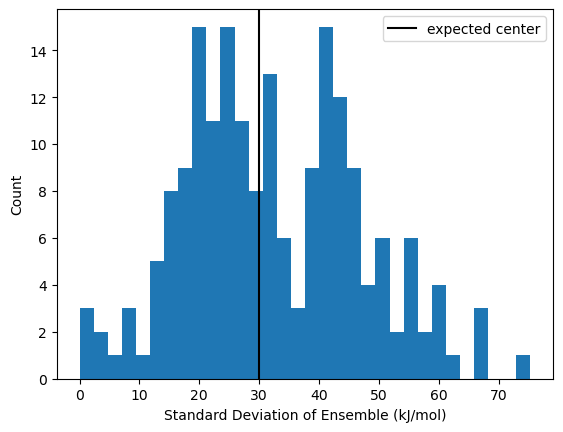

In [11]:
# as of 2026, the BEEF errors should be on the order of 30 kJ/mol, but this may change over time!
assert np.sum(np.diagonal(cov_Hf) == 0) <= 1, 'There should not be any zeros in the diagonal of the covariance matrix'
assert np.sum(np.isnan(cov_Hf)) == 0, 'There should not be any nans in the covariance matrix'

tolerance = 1e-12
assert np.linalg.eigvals(cov_Hf).all() > -tolerance, 'Covariance matrix should be positive semidefinite'

diagonal = np.diagonal(cov_Hf)
plt.figure()
plt.hist(np.sqrt(diagonal), bins=32)
plt.axvline(x=30, color='black', label='expected center')
plt.ylabel('Count')
plt.xlabel('Standard Deviation of Ensemble (kJ/mol)')
plt.legend()

# check that the mean uncertainty is +/- 10 kJ/mol of the expected 30 kJ/mol
assert np.isclose(np.mean(np.sqrt(diagonal)), 30, atol=10.0)


Text(0.5, 1.0, 'Thermo Covariance Matrix')

<Figure size 640x480 with 0 Axes>

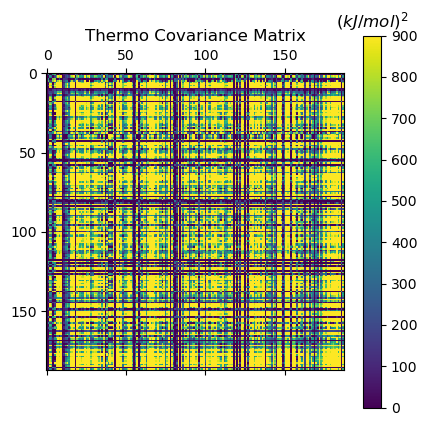

In [12]:
plt.figure()
# Look at the covariance matrix
plt.matshow(cov_Hf)
cb = plt.colorbar()
plt.clim([0, 30 ** 2])
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')

### 1.6 Save files

In [13]:
lib_name = os.path.basename(thermo_lib_file).replace('.py', '')
thermo_uncertainty_dir = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', lib_name)
os.makedirs(thermo_uncertainty_dir, exist_ok=True)

# # numpy format
# cov_mat_file = os.path.join(thermo_uncertainty_dir, 'covariance.npy')
# np.save(cov_mat_file, cov_Hf)

# CSV format
cov_mat_csv_file = os.path.join(thermo_uncertainty_dir, 'covariance.csv')
df = pd.DataFrame(columns=molecule_labels, data=cov_Hf)
df.to_csv(cov_mat_csv_file, index=False)

# labels need to be unique, and shorter than 16 characters
spec_list = []
for i in range(len(molecules)):
    spec = rmgpy.species.Species(molecule=[molecules[i]])
    spec.label = f'{molecules[i].smiles}({i})'
    if len(spec.label) > 10:  # <----- try decreasing this if not all species are saved
        spec.label = molecules[i].get_formula() + f'({i})'
    spec_list.append(spec)

rmgpy.chemkin.save_species_dictionary(
    os.path.join(thermo_uncertainty_dir, 'species_dictionary.txt'),
    spec_list,
)

# read it back in to check we didn't lose any
sp_dict = rmgpy.chemkin.load_species_dictionary(os.path.join(thermo_uncertainty_dir, 'species_dictionary.txt'))
assert len(sp_dict) == len(molecules), 'not all species were saved, try decreasing label length limit'

# Part 2: Pt111 adsorption correction tree correlations

### 2.1 Load the adsorption correction tree from the database

In [14]:
database = rmgpy.data.rmg.RMGDatabase()

database.load(
    path = rmgpy.settings['database.directory'],
    thermo_libraries = ['surfaceThermoPt111', 'primaryThermoLibrary'],
    transport_libraries = [],
    reaction_libraries = [],
    seed_mechanisms = [],
    kinetics_families = 'none',
    kinetics_depositories = ['training'],
    depository = False,
)

INFO:root:Loading transport group database from /home/moon/rmg/RMG-database/input/transport/groups...


INFO:root:Loading frequencies library from halogens_G4.py in /home/moon/rmg/RMG-database/input/statmech/libraries...


INFO:root:Loading frequencies group database from /home/moon/rmg/RMG-database/input/statmech/groups...


INFO:root:Loading solvation thermodynamics group database from /home/moon/rmg/RMG-database/input/solvation/groups...


INFO:root:Loading thermodynamics library from surfaceThermoPt111.py in /home/moon/rmg/RMG-database/input/thermo/libraries...


INFO:root:Loading thermodynamics library from primaryThermoLibrary.py in /home/moon/rmg/RMG-database/input/thermo/libraries...


INFO:root:Loading thermodynamics group database from /home/moon/rmg/RMG-database/input/thermo/groups...


INFO:root:Loading thermodynamics SIDTs from /home/moon/rmg/RMG-database/input/thermo/sidt...


### 2.2 Flatten the adsorption correction tree groups into a single list of nodes

In [15]:
# get a list of all the adsorption correction groups
ads_group_items = [database.thermo.groups['adsorptionPt111'].entries[key].item for key in database.thermo.groups['adsorptionPt111'].entries]
ads_group_labels = [key for key in database.thermo.groups['adsorptionPt111'].entries]
ads_group_desc = [database.thermo.groups['adsorptionPt111'].entries[key].short_desc for key in database.thermo.groups['adsorptionPt111'].entries]
assert len(ads_group_items) == len(ads_group_labels)

# make a list with all groups and training species because we also want to correlate the adsorption groups with the surfaceThermoPt111 library
all_items = ads_group_items + molecules


### 2.3 Calculate covariance of the groups and training data.
#### - Assumes any training species that is subgraph isomorphic with a group is used to train that node.
#### - Also assumes each training species contributes with equal weight

In [16]:
# Make a giant matrix called ads_ensembles
# its size is (#group nodes + #species) x 2000 and it holds all the group + training species ensemble data
# Once it's filled in, we can call np.cov(ads_ensembles) to get the covariance matrix of the adsorption tree nodes
N = 2000  # size of ensemble
n_groups = len(ads_group_items)
n_molecules = len(molecules)
ads_ensembles = np.zeros((len(all_items), N))

def training_molecule_fits_group(training_molecule, group):
    # check if a species matches the general description of the group node
    return training_molecule.is_subgraph_isomorphic(group, generate_initial_map=True)

def training_molecule_fits_desc(training_molecule, desc):
    if 'anything' in desc.lower():
        return True
    # see if molecule name is in the list of molecules for that node

    start_tag = '"Averaged from: ['
    start_idx = desc.find(start_tag) + len(start_tag)
    assert start_idx >= 0
    end_tag = ']"'
    end_idx = desc.find(end_tag)

    desc = desc[start_idx:end_idx].replace('\'', '')
    tokens = desc.split(',')
    tokens = [x.strip() for x in tokens]
    return training_molecule in tokens
    

# Construct ensemble matrix for groups as average of training data
for i in range(n_groups):
    # get all molecules that match that node
    n_training_mols = 0
    for j in range(n_molecules):
        # if training_molecule_fits_group(molecules[j], ads_group_items[i]):
        if training_molecule_fits_desc(molecule_order[j], ads_group_desc[i]):
            ads_ensembles[i, :] += Hf_ensemble_data[j, :]
            n_training_mols += 1
    
    if n_training_mols > 0:
        ads_ensembles[i, :] /= n_training_mols
    else:
        ads_ensembles[i, :] = np.nan  # no data

# also fill in the individual species        
for i in range(n_molecules):
    ads_ensembles[n_groups + i, :] += Hf_ensemble_data[i, :]

cov_ads = np.cov(ads_ensembles)  # units are (kJ/mol) ^2

### 2.4 Check that the results make sense

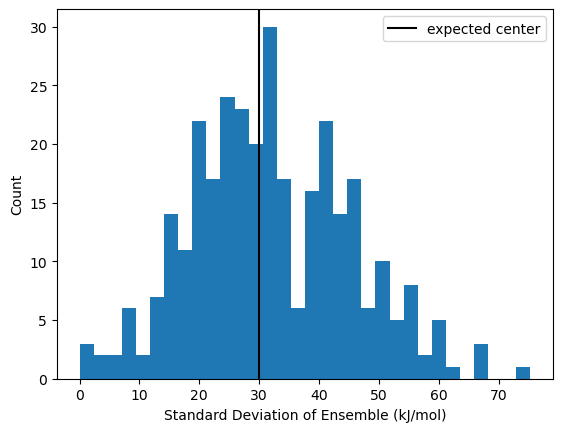

In [17]:
# as of 2026, the BEEF errors should be on the order of 30 kJ/mol, but this may change over time!
# For this covariance matrix, we expect 

# for i in range(cov_ads.shape[0]):
#     if np.isnan(cov_ads[i, i]):
#         print(f'Index {i} {all_items[i]} is missing data:')
#         display(all_items[i])
# assert np.sum(np.isnan(cov_ads)) == 0, 'Ideally, there should not be any nans in the covariance matrix'

# tolerance = 1e-12
# assert np.linalg.eigvals(cov_ads).all() > -tolerance, 'Covariance matrix should be positive semidefinite'

diagonal = np.diagonal(cov_ads)
plt.figure()
plt.hist(np.sqrt(diagonal), bins=32)
plt.axvline(x=30, color='black', label='expected center')
plt.ylabel('Count')
plt.xlabel('Standard Deviation of Ensemble (kJ/mol)')
plt.legend()

# check that the mean uncertainty is +/- 10 kJ/mol of the expected 30 kJ/mol
assert np.isclose(np.nanmean(np.sqrt(diagonal)), 30, atol=10.0)

Text(0.5, 1.0, 'Thermo Covariance Matrix')

<Figure size 640x480 with 0 Axes>

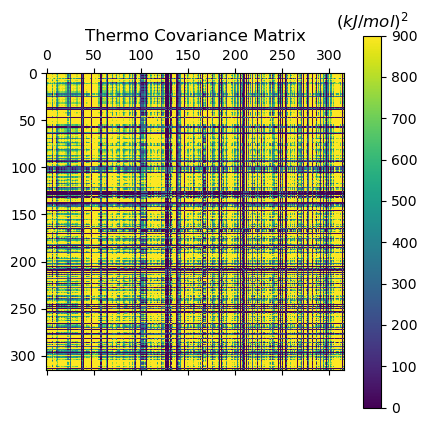

In [18]:
plt.figure()
# Look at the covariance matrix
plt.matshow(cov_ads)
cb = plt.colorbar()
plt.clim([0, 30 ** 2])
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')


### 2.5 Save the results

In [19]:
ads_thermo_uncertainty_dir = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', 'adsorptionPt111')
os.makedirs(ads_thermo_uncertainty_dir, exist_ok=True)

# # numpy file
# ads_cov_mat_file = os.path.join(ads_thermo_uncertainty_dir, 'covariance.npy')
# np.save(ads_cov_mat_file, cov_ads)

# CSV file
ads_cov_mat_labels = ads_group_labels + molecule_labels
ads_cov_mat_csv_file = os.path.join(ads_thermo_uncertainty_dir, 'covariance.csv')
df = pd.DataFrame(columns=ads_cov_mat_labels, data=cov_ads)
df.to_csv(ads_cov_mat_csv_file, index=False)


# save molecules and groups separately because it's impossible to disambiguate if they're combined
# also, groups can't be saved directly using rmgpy.chemkin.save_species_dictionary

# labels need to be unique, and shorter than 16 characters
spec_list = []
for i in range(len(molecules)):
    spec = rmgpy.species.Species(molecule=[molecules[i]])
    spec.label = f'{molecules[i].smiles}({i})'
    if len(spec.label) > 10:  # <----- try decreasing this if not all species are saved
        spec.label = molecules[i].get_formula() + f'({i})'
    spec_list.append(spec)

rmgpy.chemkin.save_species_dictionary(
    os.path.join(ads_thermo_uncertainty_dir, 'species_dictionary.txt'),
    spec_list,
)
# read it back in to check we didn't lose any
sp_dict = rmgpy.chemkin.load_species_dictionary(os.path.join(ads_thermo_uncertainty_dir, 'species_dictionary.txt'))
assert len(sp_dict) == len(molecules), 'not all species were saved, try decreasing label length limit'


# save the groups separately as a ThermoGroup Database
my_group_database = rmgpy.data.thermo.ThermoGroups()
my_group_database.name = "adsorptionPt111 uncertainty groups"
my_group_database.short_desc = "Uncertainty group definitions for adsorbates on Pt(111)"
my_group_database.long_desc = """
This database defines the adsorption-group patterns in the same order as the corresponding covariances.npy.
This is allows the uncertainty analysis to account for correlations when different groups on the same adsorption correction tree
were trained using the same DFT data.
"""
for i in range(len(ads_group_items)):
    entry = rmgpy.data.base.Entry()
    entry.item = ads_group_items[i]
    entry.label = ads_group_labels[i]
    my_group_database.entries[entry.label] = entry
my_group_database.save(os.path.join(ads_thermo_uncertainty_dir, 'groups.py'))


## 3. Spot check some specific covariances to use for direct comparison with RMG UQ

### group-group

In [20]:
ads1 = ads_group_labels.index('CXRCX')
ads2 = ads_group_labels.index('RC-X=R=C=X')
print(f'Covariance({ads_group_labels[ads1]}, {ads_group_labels[ads2]}) = {cov_ads[ads1, ads2] / 4.184 / 4.184:0.4f} (kcal/mol)^2')


Covariance(CXRCX, RC-X=R=C=X) = 129.3958 (kcal/mol)^2


### group-library

In [21]:
ads1 = ads_group_labels.index('C=XR2')

lib2 = -1
for i in range(len(molecules)):
    if molecules[i].is_isomorphic(rmgpy.molecule.Molecule(smiles='OC(=*)C')):
        lib2 = i
        break


print(f'Covariance({ads_group_labels[ads1]}, {molecules[lib2]}) = {cov_ads[ads1, n_groups + lib2] / 4.184 / 4.184:0.4f} (kcal/mol)^2')


Covariance(C=XR2, <Molecule "C[C](O)=[Pt]">) = 64.0030 (kcal/mol)^2


### library-library

In [22]:
lib1 = -1
lib2 = -1
for i in range(len(molecules)):
    if molecules[i].is_isomorphic(rmgpy.molecule.Molecule(smiles='C*')):
        lib1 = i
    if molecules[i].is_isomorphic(rmgpy.molecule.Molecule(smiles='[CH2]=*')):
        lib2 = i
    
print(f'Covariance({molecules[lib1]}, {molecules[lib2]}) = {cov_ads[n_groups + lib1, n_groups + lib2] / 4.184 / 4.184:0.4f} (kcal/mol)^2')


Covariance(<Molecule "[CH3][Pt]">, <Molecule "[CH2]=[Pt]">) = 29.4744 (kcal/mol)^2
